In [4]:
import pandas as pd
from ydata_profiling import ProfileReport

In [8]:
tata = pd.read_csv(r'C:\Users\Yuvanshu Dadhich\OneDrive\Desktop\dwdm\tata_motors_inventory.csv')
maruti = pd.read_csv(r'C:\Users\Yuvanshu Dadhich\OneDrive\Desktop\dwdm\maruti_suzuki_inventory.csv')
hyundai = pd.read_csv(r'C:\Users\Yuvanshu Dadhich\OneDrive\Desktop\dwdm\hyundai_india_inventory.csv')

In [9]:
import pandas as pd

all_car_data = pd.concat([tata, maruti, hyundai], axis=0, ignore_index=True)

In [10]:
all_car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65790 entries, 0 to 65789
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         65790 non-null  object 
 1   Company                      65790 non-null  object 
 2   Car_Model                    65790 non-null  object 
 3   Car_Type                     65790 non-null  object 
 4   Region                       65790 non-null  object 
 5   Price                        65790 non-null  float64
 6   Units_Sold                   64476 non-null  float64
 7   Stock_Quantity               64476 non-null  float64
 8   COGS                         64476 non-null  float64
 9   Avg_Inventory                65790 non-null  float64
 10  Reorder_Point                64476 non-null  float64
 11  Lead_Time_Days               64476 non-null  float64
 12  Inventory_Turnover_Ratio     65790 non-null  float64
 13  Days_Sales_Inven

In [13]:
all_car_data.to_csv(r'C:\Users\Yuvanshu Dadhich\OneDrive\Desktop\dwdm\all_car_data.csv')

In [14]:
all_car_data.columns

Index(['Date', 'Company', 'Car_Model', 'Car_Type', 'Region', 'Price',
       'Units_Sold', 'Stock_Quantity', 'COGS', 'Avg_Inventory',
       'Reorder_Point', 'Lead_Time_Days', 'Inventory_Turnover_Ratio',
       'Days_Sales_Inventory', 'Season', 'Month', 'Quarter', 'Day_of_Week',
       'Is_Weekend', 'Is_Holiday', 'Promotion_Active', 'Seasonality_Flag',
       'EV_Charging_Stations_Nearby', 'Govt_Subsidy_Applied',
       'Dealer_Network_Size', 'Service_Type', 'Warranty_Years',
       'Export_Units'],
      dtype='object')

In [15]:
all_car_data_final = all_car_data.drop(columns = ['EV_Charging_Stations_Nearby', 'Govt_Subsidy_Applied',
       'Dealer_Network_Size', 'Service_Type', 'Warranty_Years',
       'Export_Units'], axis = 1)

In [16]:
all_car_data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65790 entries, 0 to 65789
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      65790 non-null  object 
 1   Company                   65790 non-null  object 
 2   Car_Model                 65790 non-null  object 
 3   Car_Type                  65790 non-null  object 
 4   Region                    65790 non-null  object 
 5   Price                     65790 non-null  float64
 6   Units_Sold                64476 non-null  float64
 7   Stock_Quantity            64476 non-null  float64
 8   COGS                      64476 non-null  float64
 9   Avg_Inventory             65790 non-null  float64
 10  Reorder_Point             64476 non-null  float64
 11  Lead_Time_Days            64476 non-null  float64
 12  Inventory_Turnover_Ratio  65790 non-null  float64
 13  Days_Sales_Inventory      65790 non-null  float64
 14  Season

In [17]:
import pandas as pd
all_car_data_final = pd.read_csv('C:\\Users\\Yuvanshu Dadhich\\OneDrive\\Desktop\\dwdm\\all_car_data_final.csv')

In [20]:
all_car_data_final.to_csv('all_car_data_final.csv')

In [25]:
# One-hot encoding for categorical columns
columns_to_encode = ['Company', 'Car_Model', 'Car_Type', 'Day_of_Week', 'Region', 'Season']
all_car_data_final_encoded= pd.get_dummies(all_car_data_final, columns=columns_to_encode, dtype=int)

print("Original shape:", all_car_data_final.shape)
print("Encoded shape:", all_car_data_final_encoded.shape)
print("\nNew columns after encoding:")
print(all_car_data_final_encoded.columns.tolist())

Original shape: (65790, 24)
Encoded shape: (65790, 63)

New columns after encoding:
['Unnamed: 0', 'Index', 'Price', 'Units_Sold', 'Stock_Quantity', 'COGS', 'Avg_Inventory', 'Reorder_Point', 'Lead_Time_Days', 'Inventory_Turnover_Ratio', 'Days_Sales_Inventory', 'Month', 'Quarter', 'Is_Weekend', 'Is_Holiday', 'Promotion_Active', 'Seasonality_Flag', 'Day', 'Company_Hyundai India', 'Company_Maruti Suzuki', 'Company_Tata Motors', 'Car_Model_Alcazar', 'Car_Model_Baleno', 'Car_Model_Brezza', 'Car_Model_Creta', 'Car_Model_Dzire', 'Car_Model_Ertiga', 'Car_Model_Grand Vitara', 'Car_Model_Harrier', 'Car_Model_Nexon', 'Car_Model_Nexon EV', 'Car_Model_Safari', 'Car_Model_Swift', 'Car_Model_Tiago', 'Car_Model_Tigor', 'Car_Model_Tucson', 'Car_Model_Venue', 'Car_Model_Verna', 'Car_Model_i20', 'Car_Type_Compact SUV', 'Car_Type_Electric SUV', 'Car_Type_Hatchback', 'Car_Type_MPV', 'Car_Type_Premium Hatchback', 'Car_Type_Premium SUV', 'Car_Type_SUV', 'Car_Type_Sedan', 'Day_of_Week_Friday', 'Day_of_Week_Mo

In [26]:
for col in all_car_data_final_encoded.columns:
    if all_car_data_final_encoded[col].isna().any():
        print(f"{col}")

Units_Sold
Stock_Quantity
COGS
Reorder_Point
Lead_Time_Days


In [27]:
all_car_data_final_encoded.to_csv('all_car_data_final_encoded.csv', index=False)

In [28]:
from sklearn.impute import KNNImputer

columns_to_impute = ['Units_Sold', 'Stock_Quantity', 'COGS', 'Reorder_Point', 'Lead_Time_Days']

knn_imputer = KNNImputer(n_neighbors=5)

all_car_data_final_encoded[columns_to_impute] = knn_imputer.fit_transform(all_car_data_final_encoded[columns_to_impute])

In [ ]:
# Save the imputed dataset
all_car_data_final_encoded.to_csv('all_car_data_final_encoded.csv', index=False)
print("Imputed dataset saved as 'all_car_data_final_encoded.csv'")

Imputed dataset saved as 'all_car_data_final_encoded.csv'


CORRELATION MATRIX
                                   Index     Price  Units_Sold  Stock_Quantity      COGS  Avg_Inventory  Reorder_Point  Lead_Time_Days  Inventory_Turnover_Ratio  Days_Sales_Inventory         Month       Quarter    Is_Weekend    Is_Holiday  Promotion_Active  Seasonality_Flag           Day  Company_Hyundai India  Company_Maruti Suzuki  Company_Tata Motors  Car_Model_Alcazar  Car_Model_Baleno  Car_Model_Brezza  Car_Model_Creta  Car_Model_Dzire  Car_Model_Ertiga  Car_Model_Grand Vitara  Car_Model_Harrier  Car_Model_Nexon  Car_Model_Nexon EV  Car_Model_Safari  Car_Model_Swift  Car_Model_Tiago  Car_Model_Tigor  Car_Model_Tucson  Car_Model_Venue  Car_Model_Verna  Car_Model_i20  Car_Type_Compact SUV  Car_Type_Electric SUV  Car_Type_Hatchback  Car_Type_MPV  Car_Type_Premium Hatchback  Car_Type_Premium SUV  Car_Type_SUV  Car_Type_Sedan  Day_of_Week_Friday  Day_of_Week_Monday  Day_of_Week_Saturday  Day_of_Week_Sunday  Day_of_Week_Thursday  Day_of_Week_Tuesday  Day_of_Week_Wedne

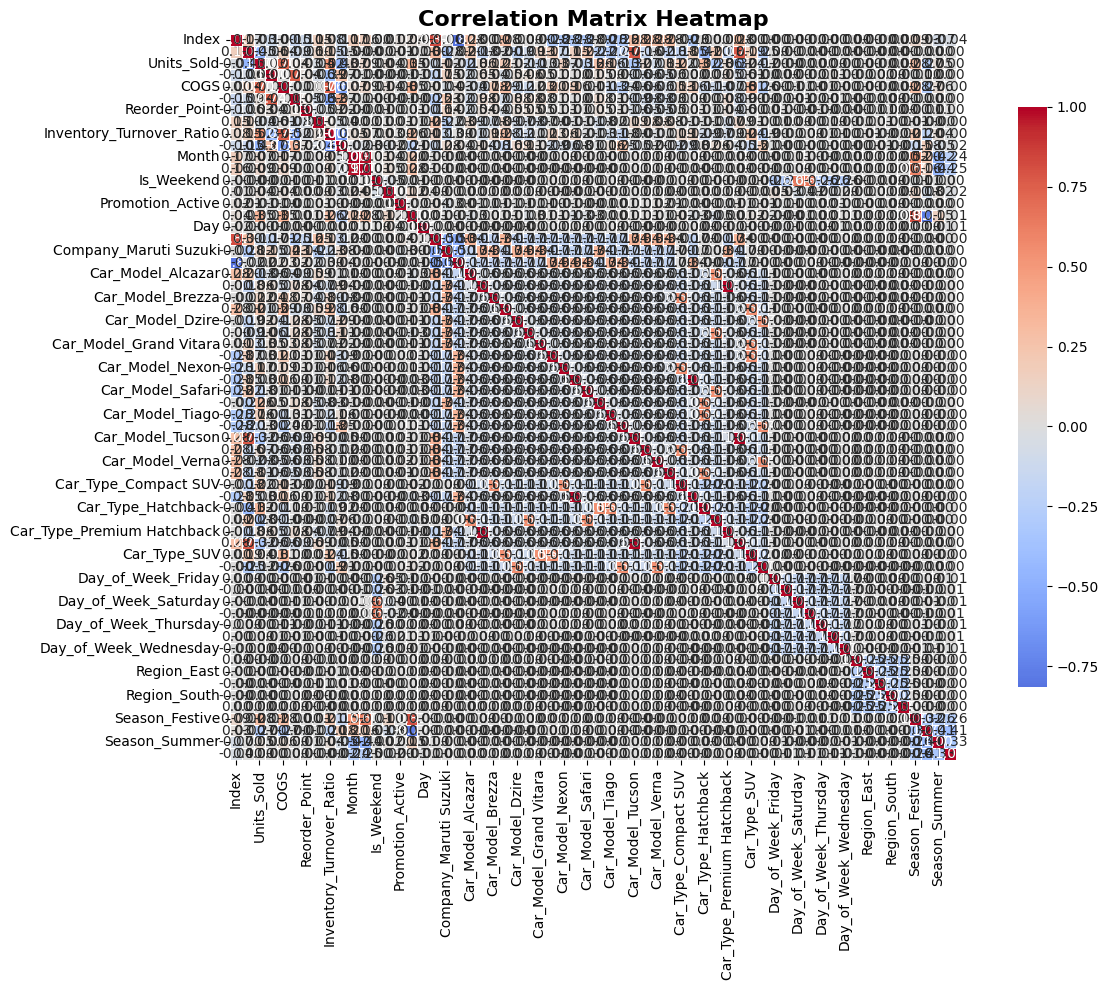


HIGHLY CORRELATED PAIRS (|correlation| > 0.7)
Index <--> Company_Hyundai India: 0.8165
Index <--> Company_Tata Motors: -0.8165
Price <--> Car_Model_Tucson: 0.7693
Price <--> Car_Type_Premium SUV: 0.7693
Units_Sold <--> COGS: 0.7031
Stock_Quantity <--> Avg_Inventory: 0.7379
COGS <--> Inventory_Turnover_Ratio: 0.7583
Month <--> Quarter: 0.9714
Seasonality_Flag <--> Season_Festive: 0.8113
Seasonality_Flag <--> Season_Monsoon: -0.7745
Car_Model_Baleno <--> Car_Type_Premium Hatchback: 1.0000
Car_Model_Nexon EV <--> Car_Type_Electric SUV: 1.0000
Car_Model_Tucson <--> Car_Type_Premium SUV: 1.0000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
correlation_matrix = all_car_data_final_encoded.corr()

# Display correlation table with better formatting
print("=" * 80)
print("CORRELATION MATRIX")
print("=" * 80)
print(correlation_matrix.to_string())

# Create a heatmap for better visualization
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs (correlation > 0.7 or < -0.7)
print("\n" + "=" * 80)
print("HIGHLY CORRELATED PAIRS (|correlation| > 0.7)")
print("=" * 80)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"{correlation_matrix.columns[i]} <--> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.4f}")

In [ ]:
from ydata_profiling import ProfileReport
all_car_data_final_encoded_profile = ProfileReport(all_car_data_final_encoded, title="All Car Data Final Encoded Profiling Report", explorative=True)
all_car_data_final_encoded_profile.to_file("all_car_data_final_encoded_profile.html")

In [ ]:

corr_matrix = all_car_data_final_encoded.corr()
corr_matrix.to_csv('correlation_matrix.csv', index=True)


In [71]:
corr_matrix = pd.read_csv('correlation_matrix.csv', index_col=0)
# Set threshold
threshold = 0.07  # change as needed

# Get correlation with target
target_corr = corr_matrix['Units_Sold']

# Filter high correlations (exclude self-correlation)
high_corr = target_corr[abs(target_corr) > threshold]
print(high_corr)
high_corr_features = high_corr.index.tolist()
for i, feature in enumerate(high_corr_features):
    print(f"{i+1}. {feature}: {target_corr[feature]:.4f}")

Price                      -0.451117
Units_Sold                  1.000000
COGS                        0.703137
Inventory_Turnover_Ratio    0.516562
Days_Sales_Inventory       -0.430618
Quarter                     0.093225
Seasonality_Flag            0.353117
Company_Hyundai India      -0.096847
Company_Maruti Suzuki       0.116338
Car_Model_Alcazar          -0.184671
Car_Model_Brezza            0.122852
Car_Model_Creta             0.214206
Car_Model_Ertiga           -0.095087
Car_Model_Grand Vitara     -0.125752
Car_Model_Nexon             0.167794
Car_Model_Safari           -0.181762
Car_Model_Swift             0.258890
Car_Model_Tiago             0.161060
Car_Model_Tigor            -0.125678
Car_Model_Tucson           -0.318609
Car_Model_Verna            -0.083229
Car_Model_i20               0.106358
Car_Type_Compact SUV        0.219598
Car_Type_Hatchback          0.323488
Car_Type_MPV               -0.283667
Car_Type_Premium SUV       -0.318609
Car_Type_Sedan             -0.116602
S

In [74]:
all_car_data_final_high_corr = all_car_data_final_encoded[high_corr_features]
all_car_data_final_high_corr.info()
all_car_data_final_high_corr.to_csv('all_car_data_final_high_corr.csv', index=False)    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65790 entries, 0 to 65789
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     65790 non-null  float64
 1   Units_Sold                65790 non-null  float64
 2   COGS                      65790 non-null  float64
 3   Inventory_Turnover_Ratio  65790 non-null  float64
 4   Days_Sales_Inventory      65790 non-null  float64
 5   Quarter                   65790 non-null  int64  
 6   Seasonality_Flag          65790 non-null  float64
 7   Company_Hyundai India     65790 non-null  int32  
 8   Company_Maruti Suzuki     65790 non-null  int32  
 9   Car_Model_Alcazar         65790 non-null  int32  
 10  Car_Model_Brezza          65790 non-null  int32  
 11  Car_Model_Creta           65790 non-null  int32  
 12  Car_Model_Ertiga          65790 non-null  int32  
 13  Car_Model_Grand Vitara    65790 non-null  int32  
 14  Car_Mo

In [111]:
all_car_data_final_high_corr = pd.read_csv('all_car_data_final_high_corr.csv')
i = 1
for col in all_car_data_final_high_corr.columns:
    print(f"{i}. {col}")
    i = i+1 

1. Price
2. Units_Sold
3. COGS
4. Inventory_Turnover_Ratio
5. Days_Sales_Inventory
6. Quarter
7. Seasonality_Flag
8. Company_Hyundai India
9. Company_Maruti Suzuki
10. Car_Model_Alcazar
11. Car_Model_Brezza
12. Car_Model_Creta
13. Car_Model_Ertiga
14. Car_Model_Grand Vitara
15. Car_Model_Nexon
16. Car_Model_Safari
17. Car_Model_Swift
18. Car_Model_Tiago
19. Car_Model_Tigor
20. Car_Model_Tucson
21. Car_Model_Verna
22. Car_Model_i20
23. Car_Type_Compact SUV
24. Car_Type_Hatchback
25. Car_Type_MPV
26. Car_Type_Premium SUV
27. Car_Type_Sedan
28. Season_Festive
29. Season_Monsoon


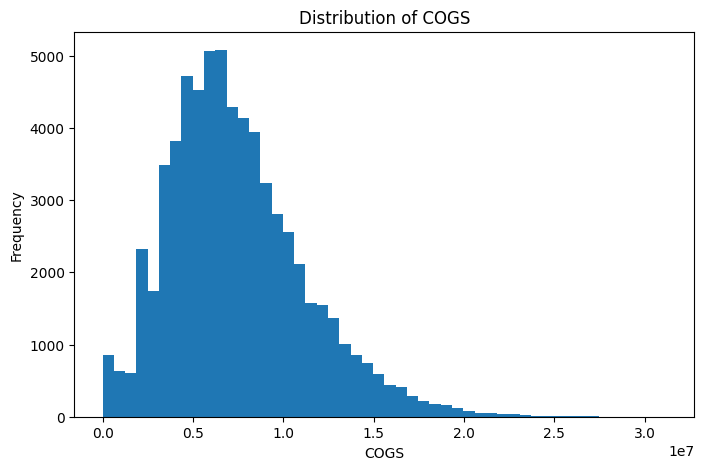

In [108]:
import matplotlib.pyplot as plt

col = 'COGS'

plt.figure(figsize=(8,5))
plt.hist(all_car_data_final_high_corr[col], bins=50)

plt.title(f'Distribution of {col}')
plt.xlabel(col)
plt.ylabel('Frequency')

plt.show()

In [113]:
import pandas as pd

outlier_summary = {}

numeric_cols = all_car_data_final_high_corr.select_dtypes(include=['number']).columns

# Remove binary columns (one-hot encoded)
valid_cols = [col for col in numeric_cols 
              if all_car_data_final_high_corr[col].nunique() > 2]

for col in valid_cols:
    
    Q1 = all_car_data_final_high_corr[col].quantile(0.25)
    Q3 = all_car_data_final_high_corr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = all_car_data_final_high_corr[
        (all_car_data_final_high_corr[col] < lower) | 
        (all_car_data_final_high_corr[col] > upper)
    ]

    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame(list(outlier_summary.items()), 
                         columns=['Column', 'Outlier_Count'])

print(outlier_df.sort_values(by='Outlier_Count', ascending=False))

                     Column  Outlier_Count
4      Days_Sales_Inventory          25644
0                     Price           3655
3  Inventory_Turnover_Ratio           1885
2                      COGS           1422
1                Units_Sold            658
5                   Quarter              0
6          Seasonality_Flag              0


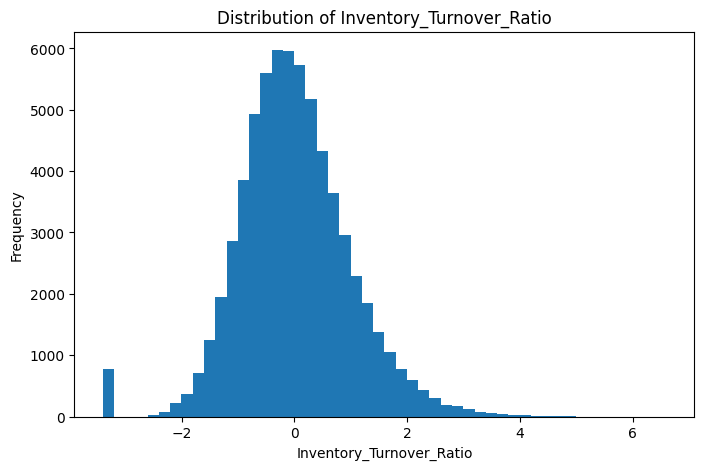

In [112]:
import numpy as np
import matplotlib.pyplot as plt

# # Step 1: Transformation
# cols = ['Days_Sales_Inventory', 'Inventory_Turnover_Ratio', 'COGS']

# for col in cols:
#     all_car_data_final_high_corr[col] = np.log1p(all_car_data_final_high_corr[col])

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

cols = [ 'Inventory_Turnover_Ratio']

all_car_data_final_high_corr[cols] = pt.fit_transform(
    all_car_data_final_high_corr[cols]
)

# Step 2: Plotting
for col in cols:
    plt.figure(figsize=(8,5))
    
    plt.hist(all_car_data_final_high_corr[col], bins=50)
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    plt.show()

In [114]:
all_car_data_final_high_corr_outlier_removed = all_car_data_final_high_corr.drop(columns = ['Days_Sales_Inventory'], axis = 1)
all_car_data_final_high_corr_outlier_removed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65790 entries, 0 to 65789
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     65790 non-null  float64
 1   Units_Sold                65790 non-null  float64
 2   COGS                      65790 non-null  float64
 3   Inventory_Turnover_Ratio  65790 non-null  float64
 4   Quarter                   65790 non-null  int64  
 5   Seasonality_Flag          65790 non-null  float64
 6   Company_Hyundai India     65790 non-null  int64  
 7   Company_Maruti Suzuki     65790 non-null  int64  
 8   Car_Model_Alcazar         65790 non-null  int64  
 9   Car_Model_Brezza          65790 non-null  int64  
 10  Car_Model_Creta           65790 non-null  int64  
 11  Car_Model_Ertiga          65790 non-null  int64  
 12  Car_Model_Grand Vitara    65790 non-null  int64  
 13  Car_Model_Nexon           65790 non-null  int64  
 14  Car_Mo

In [115]:
all_car_data_final_high_corr_outlier_removed.to_csv('all_car_data_final_high_corr_outlier_removed.csv')

In [116]:
from sklearn.model_selection import train_test_split

# X = features, y = target
X = all_car_data_final_high_corr_outlier_removed.drop(columns = 'Units_Sold', axis = 1)
y = all_car_data_final_high_corr_outlier_removed['Units_Sold']

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=1023     # reproducibility
)
print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

Training set shape: (52632, 27)
Test set shape: (13158, 27)


In [128]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

model_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model_xgb.fit(x_train, y_train)

y_pred_xgb = model_xgb.predict(x_test)

rmse_xgb = mean_squared_error(y_test, y_pred_xgb)
print("XGBoost RMSE:", rmse_xgb)

import numpy as np

mape = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
print("MAPE (%):", mape)

XGBoost RMSE: 0.773216649204837
MAPE (%): inf


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Model
model_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=1023
)

model_xgb.fit(x_train, y_train)

# Predictions
y_pred_xgb = model_xgb.predict(x_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae = mean_absolute_error(y_test, y_pred_xgb)

mape = np.mean(
    np.abs((y_test - y_pred_xgb) / np.where(y_test == 0, 1, y_test))
) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE (%):", mape)

RMSE: 0.8793273845416376
MAE: 0.28330061260278433
MAPE (%): 3.7119291582053684


In [131]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

model_rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

model_rf.fit(x_train, y_train)

y_pred_rf = model_rf.predict(x_test)

# ✅ Correct RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# ✅ MAE (always useful)
mae = mean_absolute_error(y_test, y_pred_rf)

# ⚠️ Safe MAPE
mape = np.mean(
    np.abs((y_test - y_pred_rf) / np.where(y_test == 0, 1, y_test))
) * 100

print("Random Forest RMSE:", rmse)
print("MAE:", mae)
print("MAPE (%):", mape)

Random Forest RMSE: 0.9304806009019267
MAE: 0.25257850737194093
MAPE (%): 3.3808657831349254
